# Data Cleaning

To identify what variables we want to predict, dealing with null values, getting a first grasp of the data.

Im assuming that we're moving forward with one, some, or all of the directions of analysis in readme.md. Im going to make a seperate, cleaned dataset for each.

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
df = pd.read_csv('./data/nasa_exoplanets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun        

In [93]:
# describe each column
df

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


#### String -> Class Labels

Models can't handle "Kepler7b" or whatever, so we convert all strings to numeric class labels.

In [94]:
from sklearn.preprocessing import LabelEncoder

In [95]:
string_columns = ['planet_name', 'host_star', 'discovery_method', 'disc_facility', 'planet_type', 'dist_category', 'star_type', 'orbital_period_cat']

le = LabelEncoder()

for s in string_columns: 
    df[s] = le.fit_transform(df[s])

#### Removing Highly Correlated Variables

If two variables are highly corelated (-0.9 < corr > 0.9), then those two variables essentially contain the same information and can be removed.

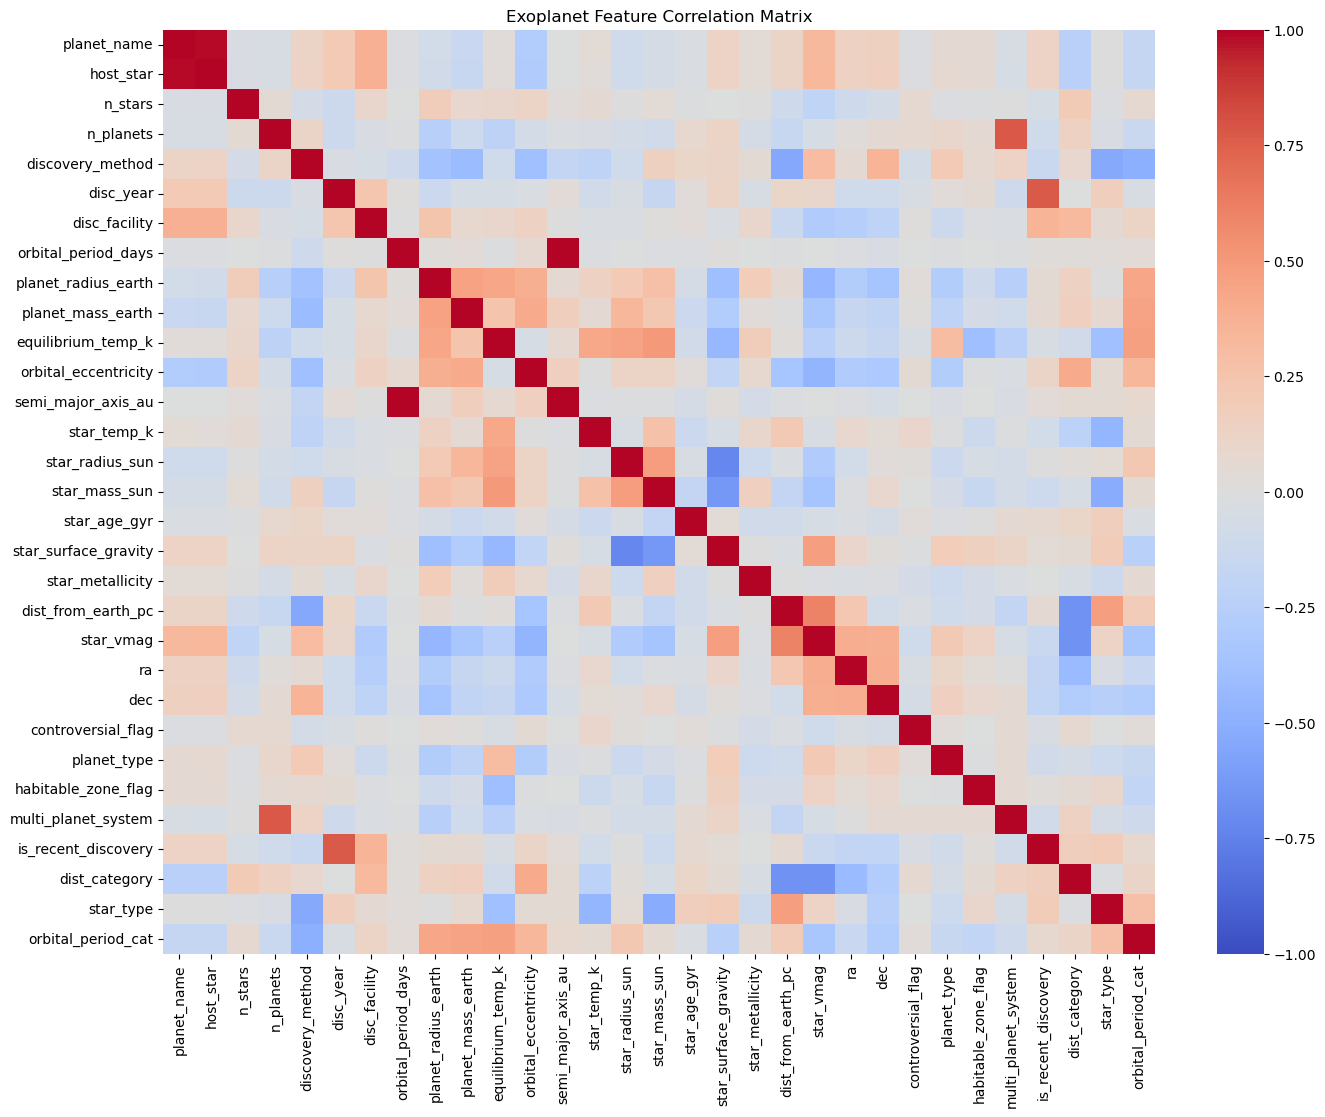

In [96]:
# casts boolean vals to 0.0 or 1.0
df = df.astype(float)

plt.figure(figsize=(16, 12))
sns.heatmap(data=df.corr(), cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Exoplanet Feature Correlation Matrix")
plt.show()

In [97]:
# the only one that I can spot that is Orbital Period in Days and Semi-Major Axis distance in AU.
df = df.drop(columns=['semi_major_axis_au'])

## Dataset Creation

As a note, im going to impute each dataset's values seperately. The target variable should be removed before imputation because of data leakage.

## 1. Planet type classification

This is a 7 class classification problem, classifiying each planet into a class. There are all 6,150 rows given, so let's start by scaling and imputing the missing values!.

In [98]:
planet_type_df = df.copy()

In [99]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [100]:
X = planet_type_df.drop(columns=['planet_type', 'planet_name', 'host_star'])
y = planet_type_df['planet_type']

Should also remove the outliers!

In [101]:
iso = IsolationForest(contamination=0.05)
yhat = iso.fit_predict(X)

# Select all rows that are NOT outliers (labeled as 1)
mask = yhat != -1
X = X[mask]
y = y[mask]

In [102]:
# scales the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# looks at the 5 closest planets to impute!
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = pd.DataFrame(imputer.fit_transform(X_scaled), columns=X_scaled.columns)

# inverse transform to get the data back to its original readable units
X_imputed = pd.DataFrame(scaler.inverse_transform(X_imputed_scaled), columns=X.columns)

# verify that there are no missing values left!
print(X_imputed.isnull().sum().sum())

0


In [103]:
y

0       4.0
1       1.0
2       3.0
3       1.0
4       2.0
       ... 
6144    0.0
6145    0.0
6147    0.0
6148    4.0
6149    0.0
Name: planet_type, Length: 5842, dtype: float64

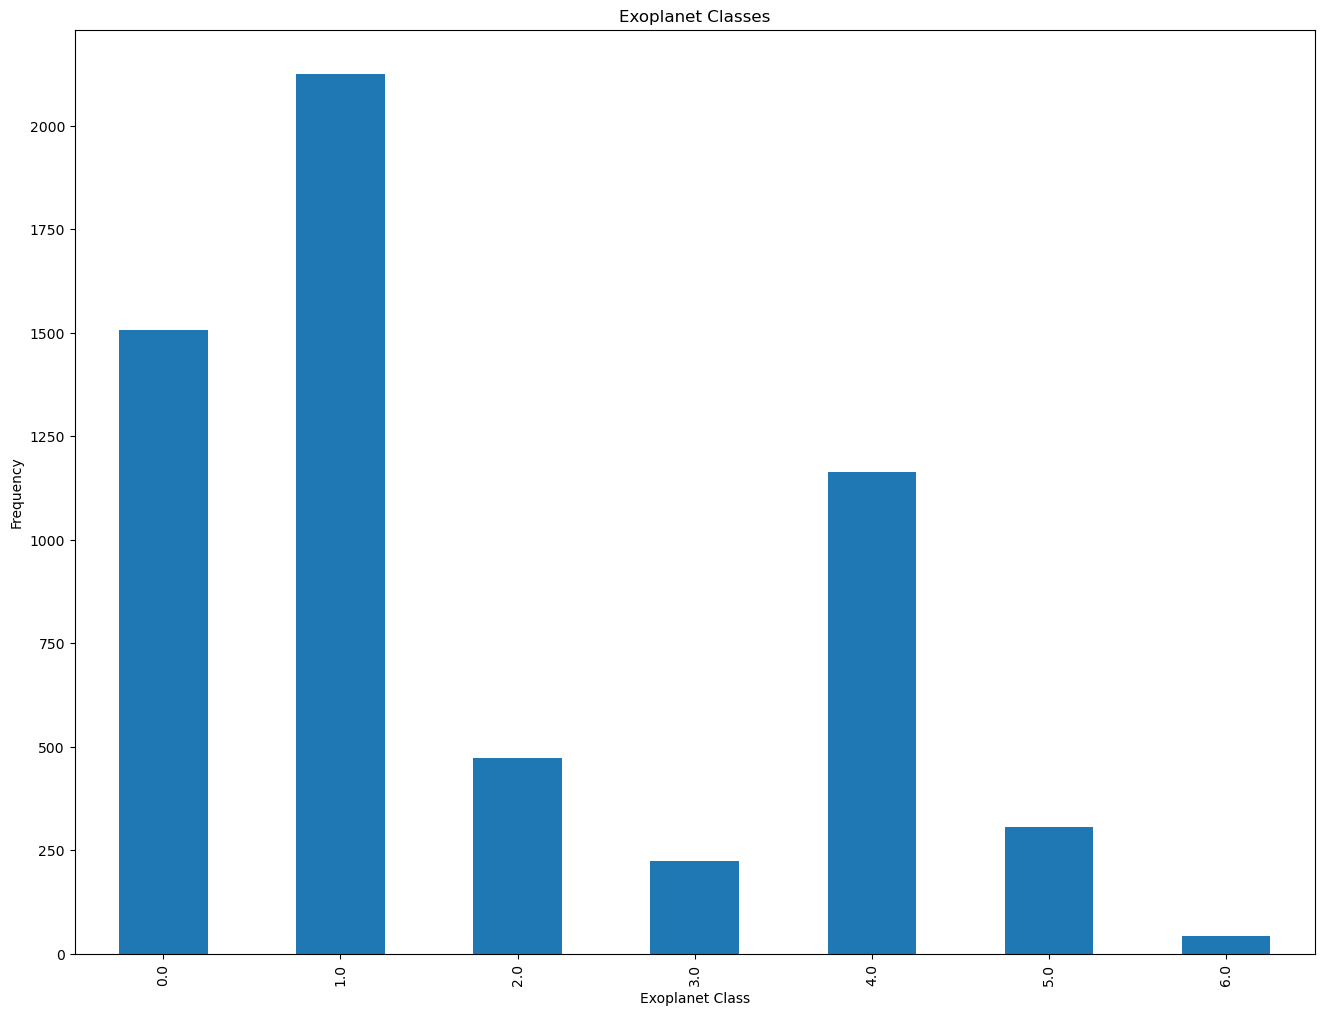

In [104]:
# let's check for a class imbalance: 
plt.figure(figsize=(16, 12))
y.value_counts().sort_index().plot(kind='bar', title='Exoplanet Classes')
plt.xlabel('Exoplanet Class')
plt.ylabel('Frequency')
plt.show()

Wowee. SMOTE time or class weighting! Gonna be interesting either way.

#### Pruning

Going to use a Random Forest to determine what variables actually matter!

In [105]:
from sklearn.ensemble import RandomForestClassifier

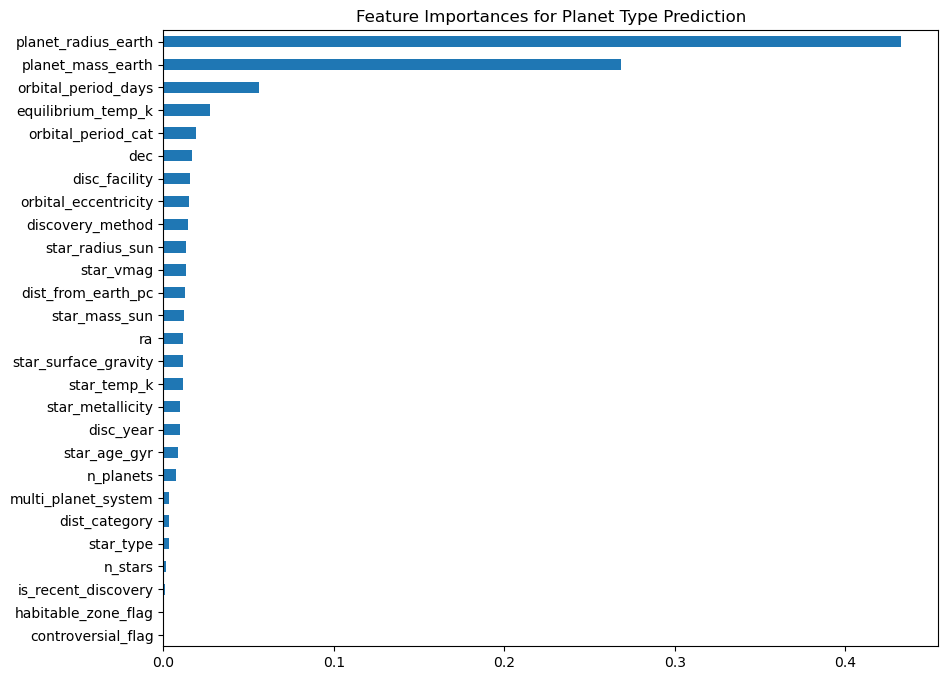

In [106]:

# Assuming missing values are handled and X, y are separated
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_imputed, y)

# Get importance scores and link them to column names
importances = pd.Series(rf.feature_importances_, index=X_imputed.columns)

# Sort and plot
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importances for Planet Type Prediction")
plt.show()

That frankly isn't that suprising. Im going to keep the first 10 variables in order of importance to planet type!

In [107]:
top_10_feature_names = importances.nlargest(10).index.tolist()

print("Top 10 Features:")
print(top_10_feature_names)

# 2. Slice your imputed/scaled dataset to ONLY include these 10 columns
X_final = X_imputed_scaled[top_10_feature_names]

# Verify the new shape (should be 6150 rows, 10 columns)
print(f"Final dataset shape: {X_final.shape}")

Top 10 Features:
['planet_radius_earth', 'planet_mass_earth', 'orbital_period_days', 'equilibrium_temp_k', 'orbital_period_cat', 'dec', 'disc_facility', 'orbital_eccentricity', 'discovery_method', 'star_radius_sun']
Final dataset shape: (5842, 10)


In [108]:
X_final.to_csv("./data/X_Planet_Type.csv")
y.to_csv("./data/Y_Planet_Type.csv")

## 2. Habitable Zone Classification

In [109]:
habitable_zone_df = df.copy()

In [110]:
X = habitable_zone_df.drop(columns=['habitable_zone_flag', 'planet_name', 'host_star'])
y = habitable_zone_df['habitable_zone_flag']

In [111]:
iso = IsolationForest(contamination=0.05)
yhat = iso.fit_predict(X)

# Select all rows that are NOT outliers (labeled as 1)
mask = yhat != -1
X = X[mask]
y = y[mask]

In [112]:
# scales the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# looks at the 5 closest planets to impute!
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = pd.DataFrame(imputer.fit_transform(X_scaled), columns=X_scaled.columns)

# inverse transform to get the data back to its original readable units
X_imputed = pd.DataFrame(scaler.inverse_transform(X_imputed_scaled), columns=X.columns)

# verify that there are no missing values left!
print(X_imputed.isnull().sum().sum())

0


In [113]:
y

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6145    0.0
6146    0.0
6147    0.0
6148    0.0
6149    0.0
Name: habitable_zone_flag, Length: 5842, dtype: float64

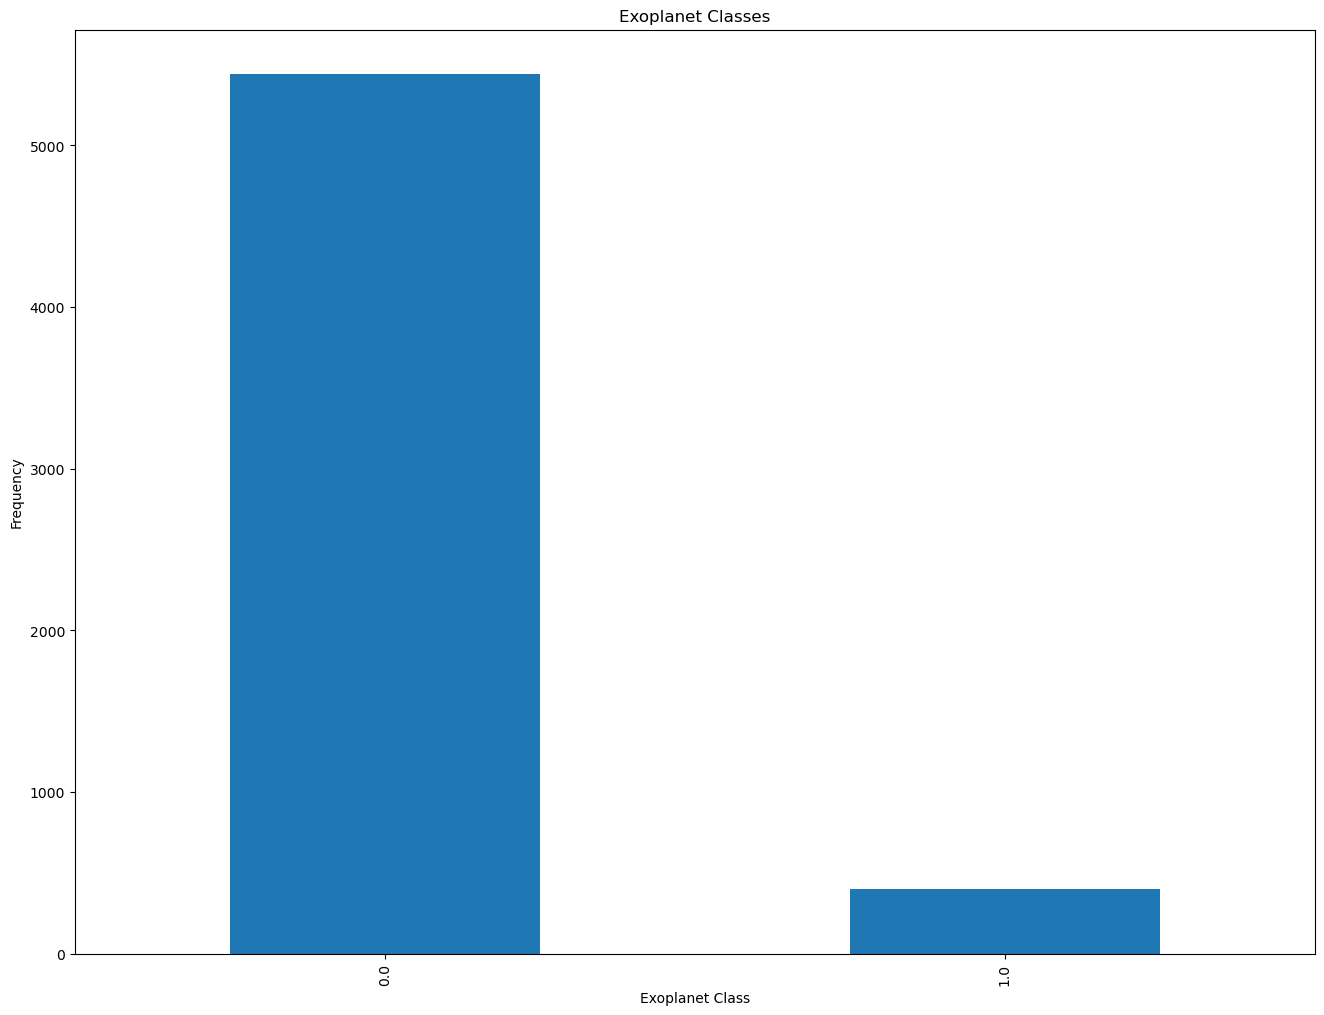

In [114]:
# let's check for a class imbalance: 
plt.figure(figsize=(16, 12))
y.value_counts().sort_index().plot(kind='bar', title='Exoplanet Classes')
plt.xlabel('Exoplanet Class')
plt.ylabel('Frequency')
plt.show()

Again, heavily imbalenced, but that's not tooooo suprising. Might have to weight this!

#### Pruning

Again, going to use a Random Forest to determine what variables actually matter!

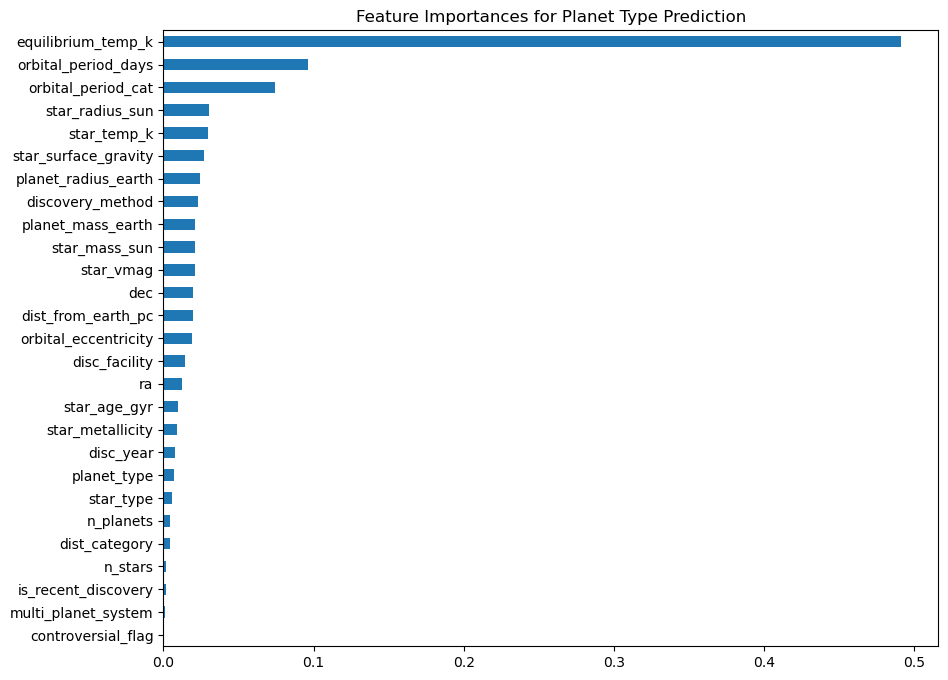

In [115]:
# Assuming missing values are handled and X, y are separated
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_imputed, y)

# Get importance scores and link them to column names
importances = pd.Series(rf.feature_importances_, index=X_imputed.columns)

# Sort and plot
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importances for Planet Type Prediction")
plt.show()

Suprisingly, there are more relevant variables in this one! For sure, equilibrium temp is very important, but others are too!

In [116]:
top_15_feature_names = importances.nlargest(15).index.tolist()

print("Top 15 Features:")
print(top_15_feature_names)

X_final = X_imputed_scaled[top_15_feature_names]

# Verify the new shape (should be 6150 rows, 15 columns)
print(f"Final dataset shape: {X_final.shape}")
X_final.to_csv("./data/X_Habitable.csv")
y.to_csv("./data/Y_Habitable.csv")

Top 15 Features:
['equilibrium_temp_k', 'orbital_period_days', 'orbital_period_cat', 'star_radius_sun', 'star_temp_k', 'star_surface_gravity', 'planet_radius_earth', 'discovery_method', 'planet_mass_earth', 'star_mass_sun', 'star_vmag', 'dec', 'dist_from_earth_pc', 'orbital_eccentricity', 'disc_facility']
Final dataset shape: (5842, 15)
